# Taller 05 · Modelos de Regresión — Predicción de Precios de Autos Usados

**Caso de negocio.** Un marketplace de autos usados necesita **estimar el precio de venta**
de un vehículo a partir de sus características (año, kilometraje, combustible, transmisión,
motor, etc.) para sugerir precios justos a vendedores y compradores.

**Tarea.** Problema de **regresión**: predecir la variable continua `selling_price`.

**Plan de trabajo**
1. Carga de datos y análisis exploratorio (EDA).
2. Preprocesamiento: limpieza de columnas de texto, encoding ordinal + One-Hot y escalado.
3. División train / test.
4. Entrenamiento de **tres** regresores: Regresión Lineal, Random Forest y Gradient Boosting.
5. Evaluación y comparación (R², RMSE, MAE; gráficas de real vs. predicho) y elección del mejor modelo.


In [1]:
# Paso 0: Importación de librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos de regresión de scikit-learn (los tres que vamos a comparar)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Utilidades de preprocesamiento, partición y métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Librerías importadas correctamente.")


Librerías importadas correctamente.


## 1. Carga de Datos y Análisis Exploratorio Inicial

Los datos provienen de [Car Price Prediction Dataset](https://www.kaggle.com/datasets/sukhmandeepsinghbrar/car-price-prediction-dataset).
El archivo `CAR DETAILS.csv` debe estar en la misma carpeta que este notebook.

In [2]:
# Paso 1: Cargar el dataset con pandas
df = pd.read_csv("CAR DETAILS.csv")

# Normalizamos los nombres de columna (quitamos espacios y unificamos a minúscula la primera)
df.columns = [c.strip() for c in df.columns]
df = df.rename(columns={"Name": "name"})

print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.\n")
df.head()


El dataset tiene 8148 filas y 13 columnas.



,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Alto 800 LXI Opt,2023,410000,10000,Petrol,Individual,Manual,First Owner,19.03 kmpl,999 CC,71.01bhp,96Nm,5.0
1,Skoda Slavia 1.0 TSI Ambition,2023,1350000,10000,Petrol,Individual,Manual,First Owner,14.08 kmpl,1956 CC,167.67bhp,350nm,5.0
2,BMW 3 Series Gran Limousine 320Ld Luxury Line,2023,5800000,1000,Diesel,Dealer,Automatic,First Owner,18.15 kmpl,998 CC,118.35bhp,172Nm,5.0
3,MG ZS EV Exclusive,2023,2650000,10000,Electric,Dealer,Automatic,First Owner,32.52 kmpl,998 CC,58.33bhp,78Nm,5.0
4,Tata Punch Adventure,2023,715000,10000,Petrol,Individual,Manual,First Owner,12.15 kmpl,1451 CC,141bhp,250Nm,5.0


In [3]:
# Tipos de datos: nota cómo mileage, engine y max_power llegan como 'object' (texto)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8148 entries, 0 to 8147
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8148 non-null   str    
 1   year           8148 non-null   int64  
 2   selling_price  8148 non-null   int64  
 3   km_driven      8148 non-null   int64  
 4   fuel           8148 non-null   str    
 5   seller_type    8148 non-null   str    
 6   transmission   8148 non-null   str    
 7   owner          8148 non-null   str    
 8   mileage        7927 non-null   str    
 9   engine         7927 non-null   str    
 10  max_power      7933 non-null   str    
 11  torque         7926 non-null   str    
 12  seats          7927 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 827.7 KB


In [4]:
# Análisis estadístico descriptivo preliminar
df.describe()


,year,selling_price,km_driven,seats
count,8148.000000,8.148000e+03,8.148000e+03,7927.000000
mean,2013.824006,6.401217e+05,6.967571e+04,5.415668
std,4.059542,8.085638e+05,5.655716e+04,0.958604
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.750000e+04,5.000000
max,2023.000000,1.000000e+07,2.360457e+06,14.000000


In [5]:
# Revisión de valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nFilas duplicadas: {df.duplicated().sum()}")


Valores nulos por columna:
name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

Filas duplicadas: 1202


### EDA visual

Exploramos la distribución del precio (target) y su relación con las variables más importantes.

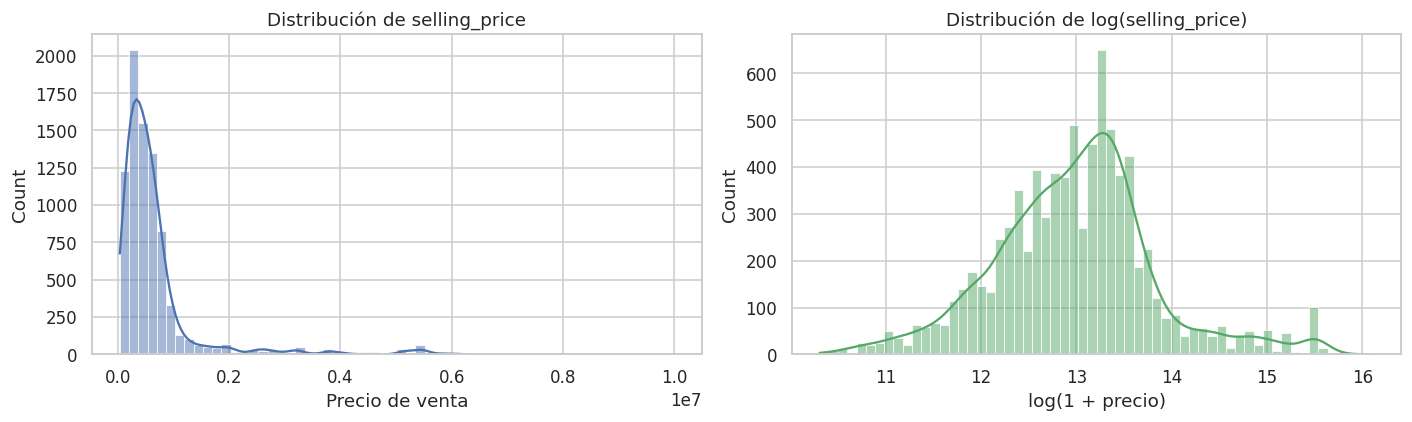

El precio está muy sesgado: la mayoría de autos son económicos y unos pocos de lujo
estiran la cola. Esto es típico en precios y conviene tenerlo en cuenta al modelar.


In [6]:
# Distribución del precio de venta (target) — fuertemente sesgado a la derecha
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["selling_price"], bins=60, kde=True, ax=axes[0], color="#4c72b0")
axes[0].set_title("Distribución de selling_price")
axes[0].set_xlabel("Precio de venta")

sns.histplot(np.log1p(df["selling_price"]), bins=60, kde=True, ax=axes[1], color="#55a868")
axes[1].set_title("Distribución de log(selling_price)")
axes[1].set_xlabel("log(1 + precio)")
plt.tight_layout()
plt.show()

print("El precio está muy sesgado: la mayoría de autos son económicos y unos pocos de lujo")
print("estiran la cola. Esto es típico en precios y conviene tenerlo en cuenta al modelar.")


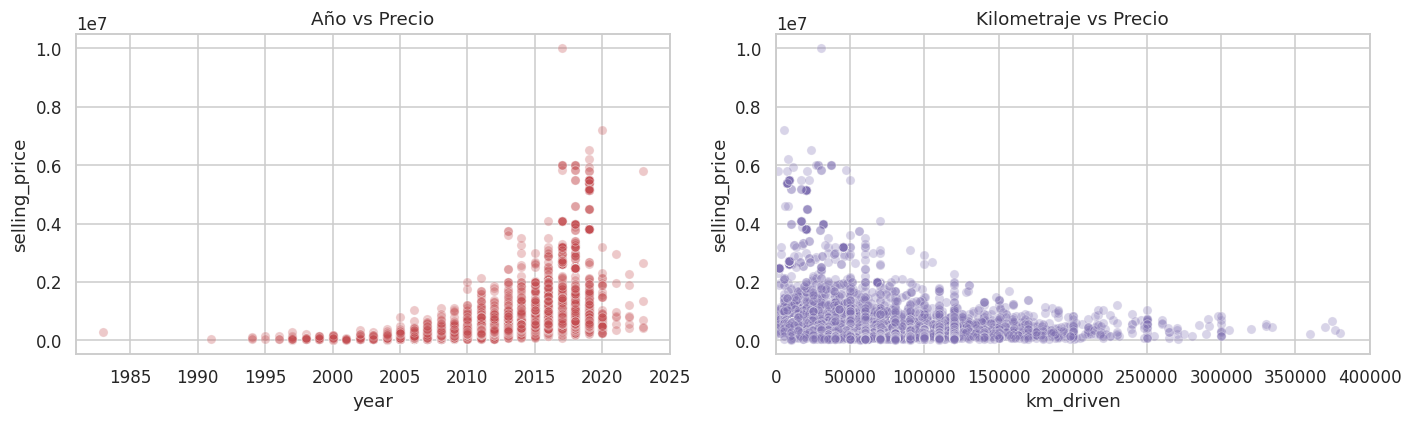

Autos más nuevos -> más caros. Más kilómetros -> más baratos. Relaciones esperadas.


In [7]:
# Relaciones clave: año vs precio y kilometraje vs precio
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.scatterplot(x="year", y="selling_price", data=df, alpha=0.3, ax=axes[0], color="#c44e52")
axes[0].set_title("Año vs Precio")
sns.scatterplot(x="km_driven", y="selling_price", data=df, alpha=0.3, ax=axes[1], color="#8172b3")
axes[1].set_title("Kilometraje vs Precio")
axes[1].set_xlim(0, 400000)
plt.tight_layout()
plt.show()

print("Autos más nuevos -> más caros. Más kilómetros -> más baratos. Relaciones esperadas.")


/tmp/ipykernel_1064/3740845106.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="fuel", y="selling_price", data=df, ax=axes[0], palette="Set3")
/tmp/ipykernel_1064/3740845106.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="transmission", y="selling_price", data=df, ax=axes[1], palette="Set3")


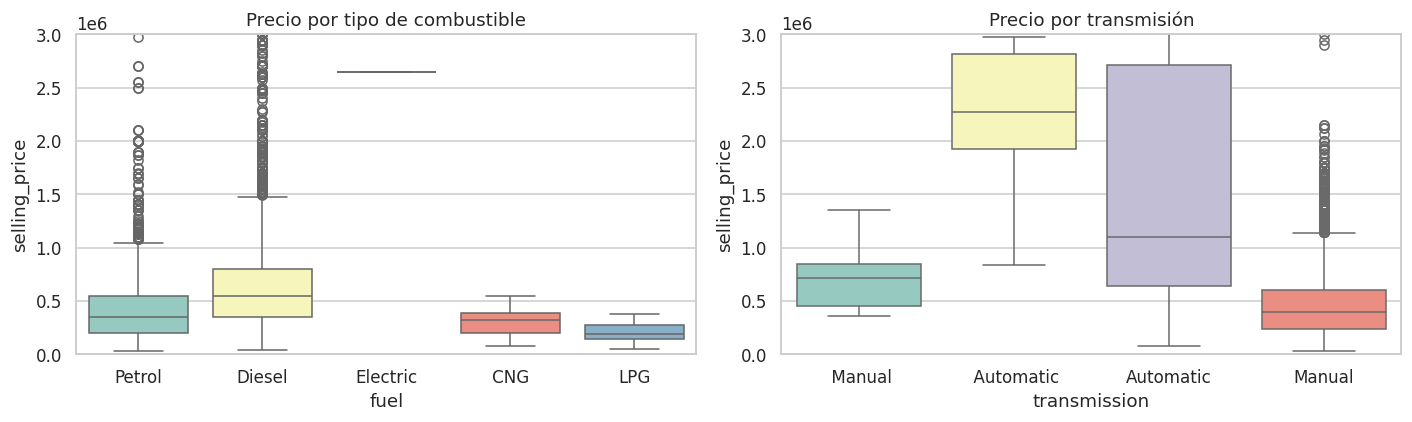

In [8]:
# Precio según combustible y transmisión
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(x="fuel", y="selling_price", data=df, ax=axes[0], palette="Set3")
axes[0].set_title("Precio por tipo de combustible")
axes[0].set_ylim(0, 3000000)
sns.boxplot(x="transmission", y="selling_price", data=df, ax=axes[1], palette="Set3")
axes[1].set_title("Precio por transmisión")
axes[1].set_ylim(0, 3000000)
plt.tight_layout()
plt.show()


## 2. Preprocesamiento de Datos e Ingeniería de Características

Aquí está el grueso del trabajo. Aplicamos cuatro tipos de transformación:

1. **Limpieza de texto** en `mileage` (`"19.03 kmpl"`), `engine` (`"999 CC"`) y
   `max_power` (`"71.01 bhp"`): extraemos solo el número y convertimos a `float`.
2. **Encoding ordinal** de `owner`, que tiene una jerarquía clara (a menos dueños, más valor).
3. **One-Hot Encoding** de `fuel`, `seller_type` y `transmission` (sin orden lógico).
4. Eliminamos `name` (alta cardinalidad) y `torque` (formato muy irregular y no requerido).

In [9]:
# Paso 2: Limpieza y transformación de datos
df_proc = df.copy()

# --- TIP 4: extraer el número de las columnas de texto ---
# Tomamos el primer número (entero o decimal) que aparezca en cada celda.
def extraer_numero(serie):
    return serie.astype(str).str.extract(r"([-+]?\d*\.?\d+)")[0].astype(float)

for col in ["mileage", "engine", "max_power"]:
    df_proc[col] = extraer_numero(df_proc[col])

# Quitamos espacios sobrantes en categóricas (transmission viene como ' Manual', ' Automatic')
for col in ["fuel", "seller_type", "transmission", "owner"]:
    df_proc[col] = df_proc[col].astype(str).str.strip()

# --- TIP 3: eliminamos columnas no útiles ---
# 'name' tiene altísima cardinalidad; 'torque' tiene un formato muy irregular.
df_proc = df_proc.drop(columns=["name", "torque"])

print("Tipos de datos tras limpiar las columnas de texto:")
print(df_proc.dtypes)


Tipos de datos tras limpiar las columnas de texto:
year               int64
selling_price      int64
km_driven          int64
fuel                 str
seller_type          str
transmission         str
owner                str
mileage          float64
engine           float64
max_power        float64
seats            float64
dtype: object


In [10]:
# Manejo de valores nulos: tras la conversión quedan algunos NaN en las numéricas.
# Los imputamos con la mediana (robusta frente a los autos de lujo atípicos).
num_con_nulos = ["mileage", "engine", "max_power", "seats"]
for col in num_con_nulos:
    df_proc[col] = df_proc[col].fillna(df_proc[col].median())

print("Nulos restantes tras la imputación:", int(df_proc.isnull().sum().sum()))


Nulos restantes tras la imputación: 0


In [11]:
# --- TIP 2: Encoding ORDINAL de 'owner' (jerarquía: menos dueños = más valor) ---
orden_owner = {
    "Test Drive Car": 0,       # prácticamente nuevo
    "First Owner": 1,
    "Second Owner": 2,
    "Third Owner": 3,
    "Fourth & Above Owner": 4,
}
df_proc["owner"] = df_proc["owner"].map(orden_owner)

print("Valores de 'owner' tras el encoding ordinal:", sorted(df_proc['owner'].unique()))


Valores de 'owner' tras el encoding ordinal: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [12]:
# --- TIP 1: One-Hot Encoding de las categóricas sin orden ---
df_proc = pd.get_dummies(
    df_proc,
    columns=["fuel", "seller_type", "transmission"],
    drop_first=True
)

# get_dummies crea booleanos; los pasamos a enteros 0/1
bool_cols = df_proc.select_dtypes(include="bool").columns
df_proc[bool_cols] = df_proc[bool_cols].astype(int)

print("Columnas finales del dataset procesado:")
print(list(df_proc.columns))
df_proc.head()


Columnas finales del dataset procesado:
['year', 'selling_price', 'km_driven', 'owner', 'mileage', 'engine', 'max_power', 'seats', 'fuel_Diesel', 'fuel_Electric', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual']


,year,selling_price,km_driven,owner,mileage,engine,max_power,seats,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual
0,2023,410000,10000,1,19.03,999.0,71.01,5.0,0,0,0,1,1,0,1
1,2023,1350000,10000,1,14.08,1956.0,167.67,5.0,0,0,0,1,1,0,1
2,2023,5800000,1000,1,18.15,998.0,118.35,5.0,1,0,0,0,0,0,0
3,2023,2650000,10000,1,32.52,998.0,58.33,5.0,0,1,0,0,0,0,0
4,2023,715000,10000,1,12.15,1451.0,141.00,5.0,0,0,0,1,1,0,1


### Escalado de los datos

Algunos modelos (como la Regresión Lineal) son sensibles a la escala de las variables.
Como `km_driven` toma valores enormes frente a, por ejemplo, `seats`, aplicamos
`StandardScaler` a la matriz de características `X`.

In [13]:
# Definición de X e y, y escalado
X = df_proc.drop(columns=["selling_price"])
y = df_proc["selling_price"]

print(f"X -> {X.shape[0]} filas y {X.shape[1]} características")
print(f"y -> objetivo 'selling_price'")


X -> 8148 filas y 14 características
y -> objetivo 'selling_price'


## 3. División del Dataset

Separamos en entrenamiento (80%) y prueba (20%) con `random_state` fijo.
Ajustamos el `StandardScaler` **solo con los datos de entrenamiento** para no filtrar
información del conjunto de prueba.

In [14]:
# Paso 3: Train/Test Split + escalado correcto (fit solo en train)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba:        {X_test.shape[0]} filas")


Entrenamiento: 6518 filas
Prueba:        1630 filas


## 4. Entrenamiento de Modelos

Entrenamos **tres** regresores distintos:

| Modelo | ¿Por qué se incluye? | ¿Usa datos escalados? |
|--------|----------------------|------------------------|
| Regresión Lineal | Modelo base, lineal e interpretable | Sí |
| Random Forest | Conjunto de árboles, capta no linealidades | No (invariante a escala) |
| Gradient Boosting | Boosting secuencial, suele ser muy preciso | No |


In [15]:
## Paso 4: Entrenamiento y evaluación de los tres modelos
modelos = {}
predicciones = {}

# --- Modelo 1: Regresión Lineal (datos escalados) ---
lin = LinearRegression()
lin.fit(X_train_scaled, y_train)
predicciones["Regresión Lineal"] = lin.predict(X_test_scaled)
modelos["Regresión Lineal"] = lin

# --- Modelo 2: Random Forest Regressor (datos sin escalar) ---
rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
predicciones["Random Forest"] = rf.predict(X_test)
modelos["Random Forest"] = rf

# --- Modelo 3: Gradient Boosting Regressor (datos sin escalar) ---
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.1,
                               max_depth=4, random_state=RANDOM_STATE)
gb.fit(X_train, y_train)
predicciones["Gradient Boosting"] = gb.predict(X_test)
modelos["Gradient Boosting"] = gb

print("Los tres modelos fueron entrenados y ya generaron predicciones sobre el conjunto de prueba.")


Los tres modelos fueron entrenados y ya generaron predicciones sobre el conjunto de prueba.


## 5. Evaluación y Comparación de Resultados

Para regresión usamos tres métricas complementarias:
- **R²**: proporción de la varianza explicada (más cerca de 1 es mejor).
- **RMSE**: error cuadrático medio (en la misma unidad del precio; menos es mejor).
- **MAE**: error absoluto medio (menos sensible a outliers; menos es mejor).

In [16]:
# Cálculo de métricas para cada modelo
resultados = []
for nombre, y_pred in predicciones.items():
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    resultados.append({
        "Modelo": nombre,
        "R2": r2_score(y_test, y_pred),
        "RMSE": rmse,
        "MAE": mean_absolute_error(y_test, y_pred),
    })

tabla = pd.DataFrame(resultados).sort_values("R2", ascending=False).reset_index(drop=True)
tabla.style.format({"R2": "{:.3f}", "RMSE": "{:,.0f}", "MAE": "{:,.0f}"})


,Modelo,R2,RMSE,MAE
0,Gradient Boosting,0.961,"154,888","72,747"
1,Random Forest,0.960,"157,430","67,794"
2,Regresión Lineal,0.675,"449,957","269,140"


/tmp/ipykernel_1064/1244910488.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Modelo", y="R2", data=tabla, palette="mako")


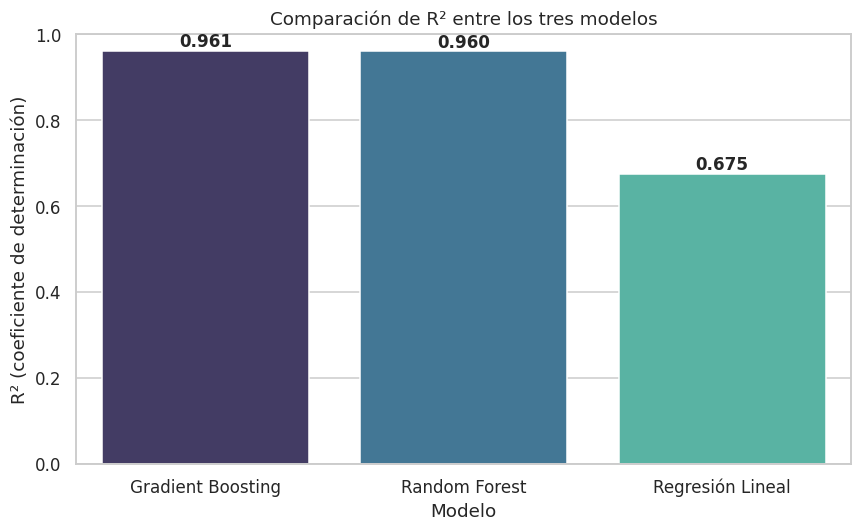

In [17]:
# Comparación de R² entre los tres modelos
plt.figure(figsize=(8, 5))
ax = sns.barplot(x="Modelo", y="R2", data=tabla, palette="mako")
plt.title("Comparación de R² entre los tres modelos")
plt.ylim(0, 1)
plt.ylabel("R² (coeficiente de determinación)")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


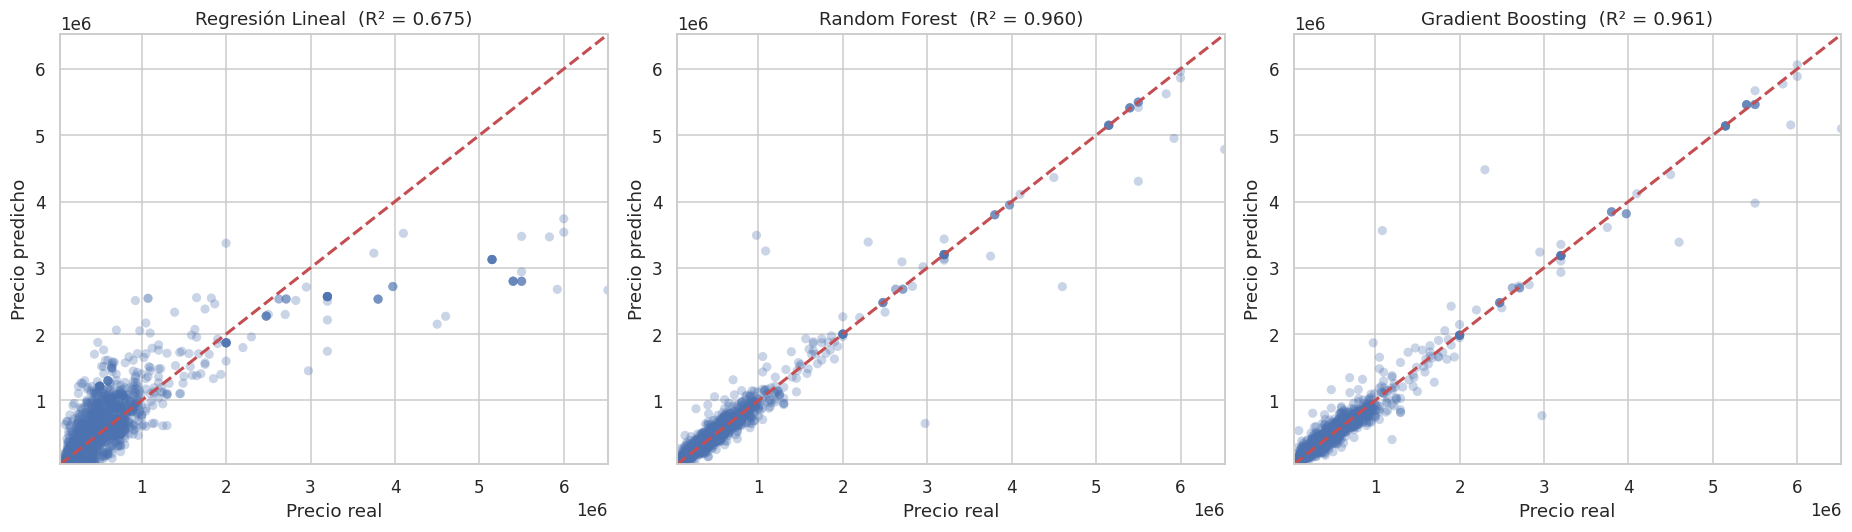

Cuanto más se peguen los puntos a la línea roja (y = x), más exactas son las predicciones.


In [18]:
# Gráfica de Valores Reales vs. Valores Predichos para cada modelo
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
lim = [y_test.min(), y_test.max()]
for ax, (nombre, y_pred) in zip(axes, predicciones.items()):
    ax.scatter(y_test, y_pred, alpha=0.3, edgecolor="none")
    ax.plot(lim, lim, "r--", linewidth=2)  # línea ideal y = x
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f"{nombre}  (R² = {r2:.3f})")
    ax.set_xlabel("Precio real")
    ax.set_ylabel("Precio predicho")
    ax.set_xlim(lim); ax.set_ylim(lim)
plt.tight_layout()
plt.show()

print("Cuanto más se peguen los puntos a la línea roja (y = x), más exactas son las predicciones.")


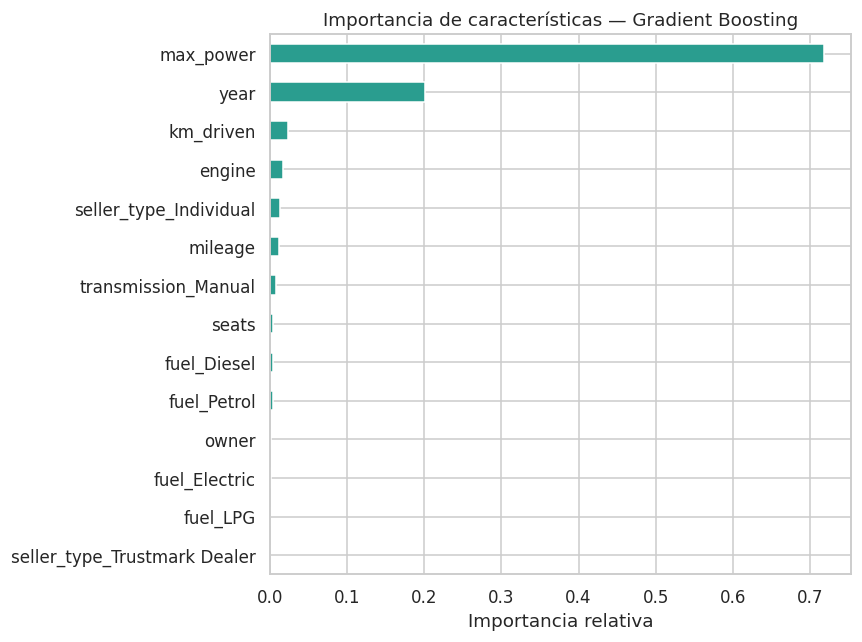

In [19]:
# Importancia de características del mejor modelo basado en árboles
mejor_arbol = rf if tabla.iloc[0]["Modelo"] == "Random Forest" else gb
nombre_arbol = "Random Forest" if mejor_arbol is rf else "Gradient Boosting"
importancias = pd.Series(mejor_arbol.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 6))
importancias.plot.barh(color="#2a9d8f")
plt.title(f"Importancia de características — {nombre_arbol}")
plt.xlabel("Importancia relativa")
plt.tight_layout()
plt.show()


## 6. Conclusión: ¿cuál es el mejor modelo?

Seleccionamos el ganador **directamente de la tabla de métricas** para que la conclusión
siempre coincida con los números de esta ejecución.

In [20]:
# Selección automática del mejor modelo según R²
mejor = tabla.iloc[0]
print(f"MEJOR MODELO: {mejor['Modelo']}")
print(f"   R2 = {mejor['R2']:.3f} | RMSE = {mejor['RMSE']:,.0f} | MAE = {mejor['MAE']:,.0f}")
print()
print("Ranking completo (por R²):")
for _, fila in tabla.iterrows():
    print(f"   {fila['Modelo']:<20} R2 = {fila['R2']:.3f} | RMSE = {fila['RMSE']:,.0f}")


MEJOR MODELO: Gradient Boosting


   R2 = 0.961 | RMSE = 154,888 | MAE = 72,747

Ranking completo (por R²):
   Gradient Boosting    R2 = 0.961 | RMSE = 154,888
   Random Forest        R2 = 0.960 | RMSE = 157,430
   Regresión Lineal     R2 = 0.675 | RMSE = 449,957


### Análisis de los resultados

- La **Regresión Lineal** sirve como línea base. Asume una relación lineal entre las
  variables y el precio, pero el precio de un auto depende de interacciones no lineales
  (depreciación por año, saltos por marca/segmento), por lo que obtiene el **menor R²**.

- Los **modelos basados en árboles (Random Forest y Gradient Boosting)** mejoran de forma
  notable porque capturan esas relaciones no lineales y las interacciones entre variables.
  La gráfica de **real vs. predicho** lo muestra: sus nubes de puntos se ajustan mucho mejor
  a la línea ideal `y = x`.

- El **mejor modelo de esta ejecución es el que encabeza el ranking de arriba**. La gráfica
  de **importancia de características** indica que `year` (antigüedad), `max_power` y
  `engine` son los factores que más pesan en el precio, lo cual tiene sentido de negocio.

**Conclusión:** elegimos el modelo basado en árboles que lidera la tabla de métricas, porque
ofrece el mayor R² y el menor error (RMSE/MAE), y además explica qué variables impulsan el
precio — información directamente útil para sugerir avalúos en el marketplace.
